# Proyecto integrador de Machine Learning

## Predicción de la suscripción a depósitos a plazo

**Asignatura:** Aprendizaje Automático y Minería de Datos  
**Programa:** Maestría en Gestión y Analítica de Datos  
**Docente:** Adriana Collaguazo Jaramillo, Mg.  
**Integrantes:** _Ritter Briones, Anthony Polo, Mariana Mora_  
**Dataset:** Bank Marketing - UCI Machine Learning Repository

## 1. Contexto y definición del problema

Las campañas de marketing telefónico requieren seleccionar clientes con una mayor probabilidad de aceptar el producto ofrecido. El objetivo es construir un modelo que ayude a identificar, antes de realizar la llamada, si un cliente podría contratar un depósito a plazo.

### Pregunta del proyecto

> ¿En qué medida las características demográficas, financieras y/o el historial de campañas permiten predecir si un cliente de la institución bancaria contratará un depósito a plazo, sin utilizar información que solamente se conoce después de finalizar la llamada?

### Tipo de problema

Nuestro proyecto es de **Clasificación Binaria Supervisada** porque buscamos clasificar a cada cliente en una de dos categorías: contratará o no contratará el depósito. Es supervisada porque el modelo aprende utilizando registros históricos donde ya conocemos el resultado real de cada campaña.

### Variable objetivo

La variable objetivo es la columna y.

Esta indica si el cliente contrató un depósito a plazo:

- `yes`: el cliente contrató el depósito.
- `no`: el cliente no contrató el depósito.

### Objetivo general

Desarrollar y comparar modelos de clasificación que permitan anticipar, a partir de información histórica, si un cliente podría contratar un depósito a plazo.

### Objetivos específicos

1. Revisar la estructura del dataset y comprobar la calidad de la información disponible.
2.	Explorar las variables financieras, demográficas y relacionadas con las campañas de contacto.
3.	Preparar las variables numéricas y categóricas para que puedan ser utilizadas correctamente por los modelos.
4.	Entrenar y comparar una regresión logística y un árbol de decisión.
5.	Evaluar el desempeño mediante métricas adecuadas para un problema de clasificación desbalanceado.
6.	Analizar cómo influyen el umbral de decisión, el desbalance de clases y el posible sobreajuste.
7.	Reconocer limitaciones, posibles fugas de información y consideraciones éticas antes de pensar en un uso real del modelo.

## 2. Fuente y justificación del dataset

Se utiliza **Bank Marketing**, disponible públicamente en el UCI Machine Learning Repository. El archivo seleccionado es `bank-full.csv`, que contiene todas las observaciones de la versión clásica del dataset.

- **Fuente:** https://archive.ics.uci.edu/dataset/222/bank+marketing
- **DOI:** https://doi.org/10.24432/C5K306
- **Licencia:** Creative Commons Attribution 4.0 (CC BY 4.0)
- **Variable objetivo:** `y`

Se eligio este dataset porque contiene más de 300 registros, combina variables numéricas y categóricas, posee una variable objetivo clara y no contiene identificadores personales directos.

## 3. Preparación del entorno

In [1]:
# Importación de librerías.

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
PALETA = {"no": "#4472C4", "yes": "#ED7D31"}

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 4. Carga del dataset


In [2]:
# Rutas compatibles con Google Colab y con un repositorio de GitHub
df = pd.read_csv("/content/bank-full.csv", sep=";")
print("Datos cargados desde el archivo local.")

print("Dimensiones (filas, columnas):", df.shape)
df.head()


Datos cargados desde el archivo local.
Dimensiones (filas, columnas): (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 5. Diccionario de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Numérica | Edad del cliente |
| `job` | Categórica | Ocupación |
| `marital` | Categórica | Estado civil |
| `education` | Categórica | Nivel educativo |
| `default` | Categórica | Incumplimiento crediticio |
| `balance` | Numérica | Saldo anual promedio en euros |
| `housing` | Categórica | Préstamo hipotecario |
| `loan` | Categórica | Préstamo personal |
| `contact` | Categórica | Medio de contacto |
| `day` | Numérica | Día del último contacto |
| `month` | Categórica | Mes del último contacto |
| `duration` | Numérica | Duración de la llamada en segundos |
| `campaign` | Numérica | Contactos realizados durante la campaña |
| `pdays` | Numérica | Días desde el contacto anterior; `-1` significa que no existió contacto previo |
| `previous` | Numérica | Contactos realizados antes de la campaña actual |
| `poutcome` | Categórica | Resultado de la campaña anterior |
| `y` | Objetivo | Contrató o no el depósito |

## 6. Exploración y calidad de los datos

In [3]:
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# Identificar valores NaN y textos vacíos, como "" o espacios
columnas_texto = df.select_dtypes(include="object").columns

vacios_texto = pd.Series(0, index=df.columns, dtype="int64")
vacios_texto.loc[columnas_texto] = df[columnas_texto].apply(
    lambda columna: columna.str.strip().eq("").sum()
)

nulos = df.isna().sum()
total_vacios = nulos + vacios_texto

resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": nulos,
    "vacios_texto": vacios_texto,
    "total_vacios": total_vacios,
    "porcentaje_vacios": (total_vacios / len(df) * 100).round(2),
    "valores_unicos": df.nunique(),
})

print(f"Filas duplicadas exactas: {df.duplicated().sum():,}")
display(resumen_calidad)

columnas_con_vacios = resumen_calidad[
    resumen_calidad["total_vacios"] > 0
]

print("\nColumnas con valores vacíos:")
if columnas_con_vacios.empty:
    print("No se encontraron columnas con valores nulos o textos vacíos.")
else:
    display(columnas_con_vacios)


Filas duplicadas exactas: 0


,tipo,nulos,vacios_texto,total_vacios,porcentaje_vacios,valores_unicos
age,int64,0,0,0,0.0,77
job,object,0,0,0,0.0,12
marital,object,0,0,0,0.0,3
education,object,0,0,0,0.0,4
default,object,0,0,0,0.0,2
balance,int64,0,0,0,0.0,7168
housing,object,0,0,0,0.0,2
loan,object,0,0,0,0.0,2
contact,object,0,0,0,0.0,3
day,int64,0,0,0,0.0,31



Columnas con valores vacíos:
No se encontraron columnas con valores nulos o textos vacíos.


### Valores `unknown`

El dataset no presenta nulos tradicionales, pero utiliza `unknown` para representar información desconocida. Estos valores se conservarán como una categoría para no eliminar observaciones útiles.

In [5]:
columnas_texto = df.select_dtypes(include="object").columns
registros_unknown = []

for columna in columnas_texto:
    cantidad = int((df[columna] == "unknown").sum())
    if cantidad > 0:
        registros_unknown.append({
            "variable": columna,
            "cantidad_unknown": cantidad,
            "porcentaje": cantidad / len(df) * 100,
        })

tabla_unknown = pd.DataFrame(registros_unknown).sort_values(
    "porcentaje", ascending=False
)
tabla_unknown["porcentaje"] = tabla_unknown["porcentaje"].round(2)
display(tabla_unknown)

,variable,cantidad_unknown,porcentaje
3,poutcome,36959,81.75
2,contact,13020,28.80
1,education,1857,4.11
0,job,288,0.64


Los valores **`unknown`** se conservaron como categorías independientes, debido a que representan información no disponible y podrían aportar información predictiva. No se reemplazaron por la moda porque esto implicaría asignar categorías sin evidencia y modificar la distribución original.

La revisión de calidad confirmó que el dataset fijo no contiene valores `NaN` ni textos vacíos. Por esta razón, no se aplicará imputación en el pipeline de transformación.


### Estadística descriptiva

Se examinan las variables numéricas para identificar rangos, dispersión y posibles valores extremos.

In [6]:
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


## 7. Análisis de la variable objetivo

,cantidad,porcentaje
y,,
no,39922,88.3
yes,5289,11.7


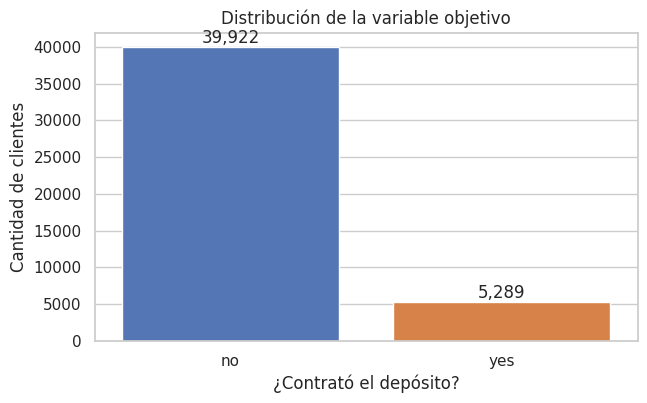

In [7]:
conteo_objetivo = df["y"].value_counts()
porcentaje_objetivo = (df["y"].value_counts(normalize=True))*100

tabla_objetivo = pd.DataFrame({
    "cantidad": conteo_objetivo,
    "porcentaje": porcentaje_objetivo.round(2),
})
display(tabla_objetivo)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="y", hue="y", palette=PALETA, legend=False, ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("¿Contrató el depósito?")
ax.set_ylabel("Cantidad de clientes")
for contenedor in ax.containers:
    #ax.bar_label(contenedor, fmt="{:,.0f}")
    ax.bar_label(contenedor, fmt="{:,.0f}")
plt.show()

### Interpretación

La clase `no` es considerablemente mayor que la clase `yes`; por lo tanto, el dataset está desbalanceado. Un modelo que predijera siempre `no` podría alcanzar un accuracy alto sin identificar correctamente a los clientes interesados. Por ello, se evaluarán conjuntamente precision, recall y F1-score.

## 8. Visualizaciones exploratorias

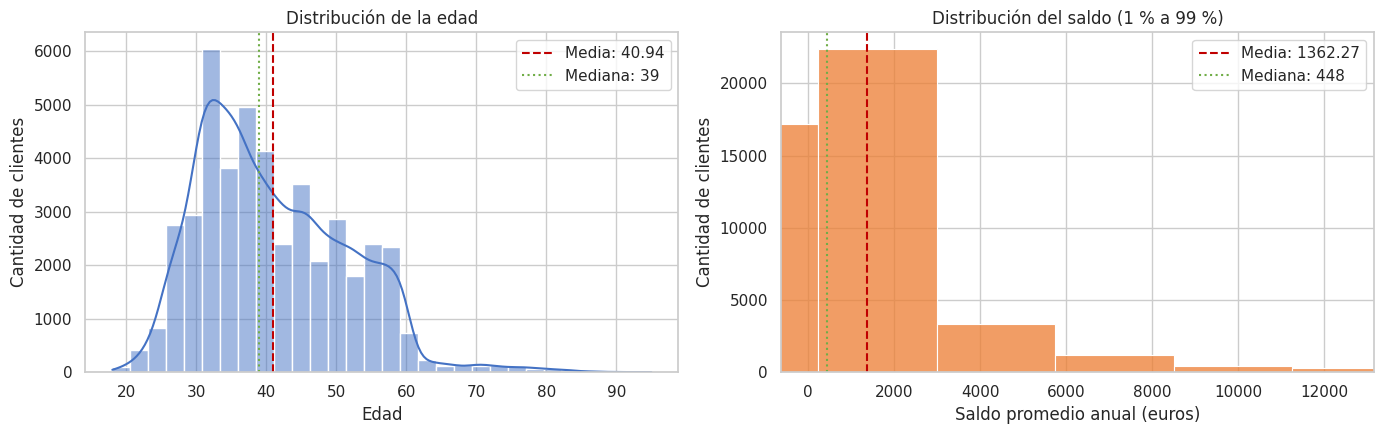

Edad: media = 40.94; mediana = 39
Saldo: media = 1362.27 euros; mediana = 448 euros


In [8]:
media_edad = df["age"].mean()
mediana_edad = df["age"].median()
media_balance = df["balance"].mean()
mediana_balance = df["balance"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="#4472C4",
    ax=axes[0],
)
axes[0].axvline(
    media_edad,
    color="#C00000",
    linestyle="--",
    label=f"Media: {media_edad:.2f}",
)
axes[0].axvline(
    mediana_edad,
    color="#70AD47",
    linestyle=":",
    label=f"Mediana: {mediana_edad:.0f}",
)
axes[0].set_title("Distribución de la edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].legend()

sns.histplot(
    data=df,
    x="balance",
    bins=40,
    color="#ED7D31",
    ax=axes[1],
)
axes[1].axvline(
    media_balance,
    color="#C00000",
    linestyle="--",
    label=f"Media: {media_balance:.2f}",
)
axes[1].axvline(
    mediana_balance,
    color="#70AD47",
    linestyle=":",
    label=f"Mediana: {mediana_balance:.0f}",
)
axes[1].set_xlim(
    df["balance"].quantile(0.01),
    df["balance"].quantile(0.99),
)
axes[1].set_title("Distribución del saldo (1 % a 99 %)")
axes[1].set_xlabel("Saldo promedio anual (euros)")
axes[1].set_ylabel("Cantidad de clientes")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Edad: media = {media_edad:.2f}; mediana = {mediana_edad:.0f}")
print(
    f"Saldo: media = {media_balance:.2f} euros; "
    f"mediana = {mediana_balance:.0f} euros"
)


### Interpretación

- La mayoría de los clientes se concentra entre los 30 y 50 años. La edad promedio es de **40.94 años** y la mediana es de **39 años**. Como ambos valores son cercanos, la distribución central de la edad no presenta una diferencia extrema entre promedio y mediana.
- El saldo presenta una distribución fuertemente asimétrica hacia la derecha. Su promedio es de **1.362,27 euros**, mientras que la mediana es de **448 euros**. Esta diferencia indica que unos pocos saldos muy elevados aumentan considerablemente el promedio.
- Para que el histograma del saldo sea legible, el eje se muestra entre los percentiles 1 y 99. Este límite solo modifica la visualización; no elimina registros del dataset.


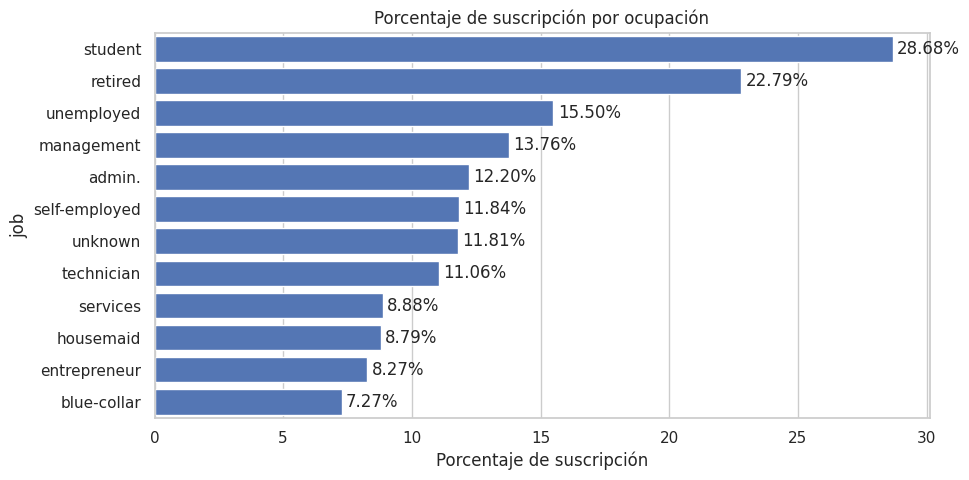

In [9]:
df_eda = df.assign(y_num=df["y"].map({"no": 0, "yes": 1}))

def graficar_tasa(variable, titulo, orden=None):
    tasa = (
        df_eda.groupby(variable, observed=False)["y_num"]
        .mean()
        .mul(100)
    )
    if orden is not None:
        tasa = tasa.reindex(orden).dropna()
    else:
        tasa = tasa.sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=tasa.values, y=tasa.index, color="#4472C4")
    plt.title(titulo)
    plt.xlabel("Porcentaje de suscripción")
    plt.ylabel(variable)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3)
    plt.show()

graficar_tasa("job", "Porcentaje de suscripción por ocupación")

## Interpretación

La tasa de suscripción varía según la ocupación. Los estudiantes y jubilados presentan los porcentajes más altos, con 28,68 % y 22,79 %, respectivamente, mientras que los clientes clasificados como blue-collar registran la tasa más baja, con 7,27 %.

Sin embargo, estos porcentajes deben analizarse junto con el tamaño de cada grupo: aunque los estudiantes tienen la mayor tasa, la categoría management aporta más suscripciones en términos absolutos. El gráfico muestra una asociación entre ocupación y suscripción, pero no demuestra que la ocupación sea la causa de la decisión del cliente.

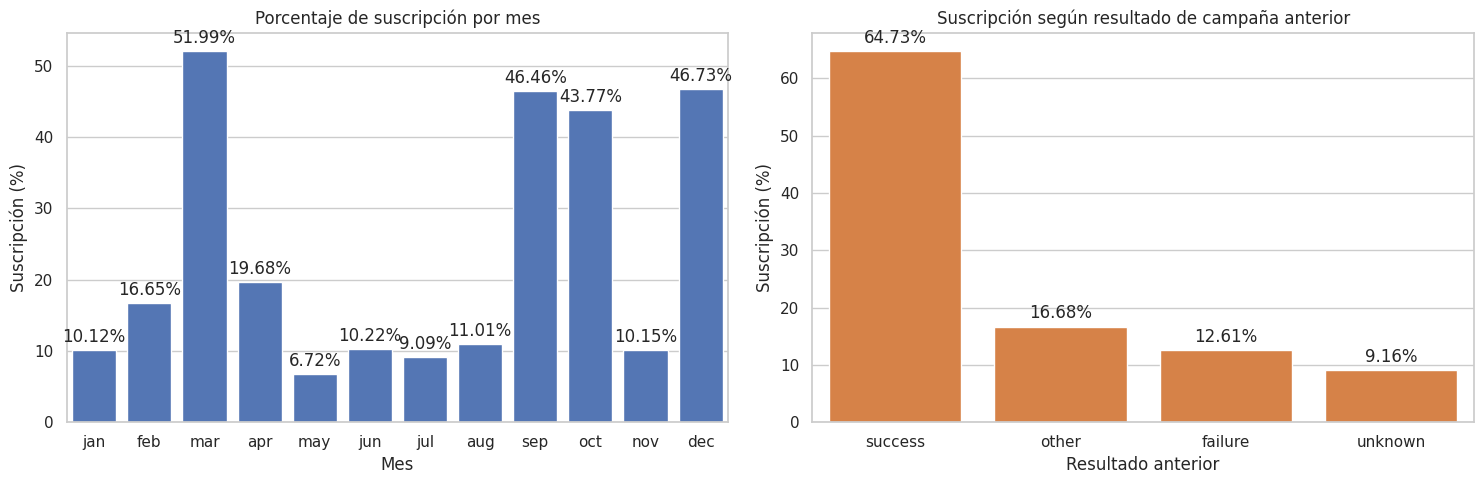

In [10]:
df_eda = df.assign(y_num=df["y"].map({"no": 0, "yes": 1}))

orden_meses = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tasa_mes = (
    df_eda.groupby("month", observed=False)["y_num"]
    .mean()
    .mul(100)
    .reindex(orden_meses)
    .dropna()
)
ax1 = sns.barplot(x=tasa_mes.index, y=tasa_mes.values, color="#4472C4", ax=axes[0])
axes[0].set_title("Porcentaje de suscripción por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Suscripción (%)")
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f%%', padding=3)

tasa_previa = (
    df_eda.groupby("poutcome", observed=False)["y_num"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
ax2 = sns.barplot(x=tasa_previa.index, y=tasa_previa.values, color="#ED7D31", ax=axes[1])
axes[1].set_title("Suscripción según resultado de campaña anterior")
axes[1].set_xlabel("Resultado anterior")
axes[1].set_ylabel("Suscripción (%)")
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()



*   La tasa de suscripción cambia considerablemente según el mes. Marzo presenta el porcentaje más alto, seguido de diciembre, septiembre y octubre. En contraste, mayo registra la tasa más baja. Sin embargo, los meses con tasas altas tienen una cantidad menor de observaciones, mientras que mayo concentra gran parte de las campañas. Por lo tanto, los porcentajes deben interpretarse junto con el número de clientes contactados. El resultado muestra una asociación entre el mes y la suscripción, pero no demuestra que el mes sea la causa directa de la decisión.

Cada barra se calcula de manera independiente dentro de cada mes. No representan partes de un mismo total.
Por ejemplo:
- Marzo: de todos los clientes contactados en marzo, el 51,99 % contrató.
- Septiembre: de todos los contactados en septiembre, el 46,46 % contrató.
- Diciembre: de todos los contactados en diciembre, el 46,73 % contrató.

*   Los clientes cuyo resultado en la campaña anterior fue exitoso presentan una tasa de suscripción de 64,73 %, considerablemente superior a las demás categorías. Los clientes con un resultado anterior desconocido registran la tasa más baja, con 9,16 %. Esto sugiere que el historial de campañas contiene información relevante para predecir una nueva contratación. Sin embargo, el gráfico representa una asociación estadística y no demuestra por sí solo una relación causal.



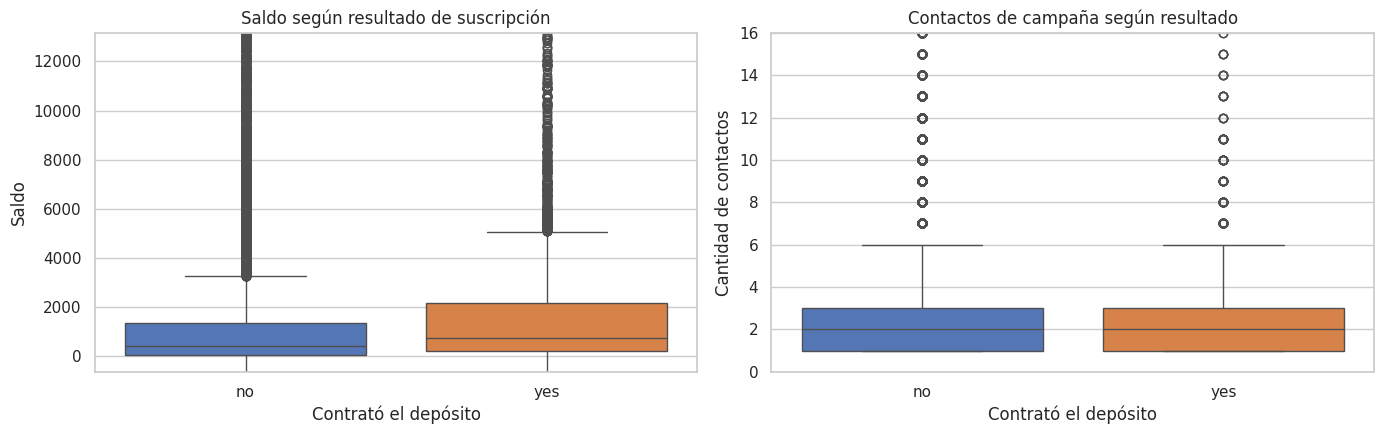

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=df, x="y", y="balance", hue="y", palette=PALETA, legend=False, ax=axes[0])
axes[0].set_ylim(df["balance"].quantile(0.01), df["balance"].quantile(0.99))
axes[0].set_title("Saldo según resultado de suscripción")
axes[0].set_xlabel("Contrató el depósito")
axes[0].set_ylabel("Saldo")

sns.boxplot(data=df, x="y", y="campaign", hue="y", palette=PALETA, legend=False, ax=axes[1])
axes[1].set_ylim(0, df["campaign"].quantile(0.99))
axes[1].set_title("Contactos de campaña según resultado")
axes[1].set_xlabel("Contrató el depósito")
axes[1].set_ylabel("Cantidad de contactos")

plt.tight_layout()
plt.show()



*   Los clientes que contrataron el depósito presentan saldos generalmente mayores que quienes no lo contrataron. La mediana del grupo yes es de 733 euros, mientras que en el grupo no es de 417 euros. Sin embargo, existe una superposición considerable entre las distribuciones y numerosos valores atípicos en ambos grupos. Esto sugiere que el saldo puede aportar información al modelo, pero no es suficiente por sí solo para determinar la suscripción.
*   La cantidad habitual de contactos es similar entre los dos grupos: ambos presentan una mediana de dos contactos y un rango central de uno a tres. No obstante, el grupo que no contrató registra un promedio ligeramente mayor y casos con una cantidad más elevada de llamadas. Esto podría indicar que aumentar repetidamente los contactos no garantiza la contratación. Sin embargo, no puede afirmarse causalidad, porque también es posible que los clientes menos interesados hayan requerido más intentos de contacto.



### Matriz de correlación

La correlación se utiliza para observar relaciones lineales entre variables numéricas. Una correlación no demuestra causalidad.

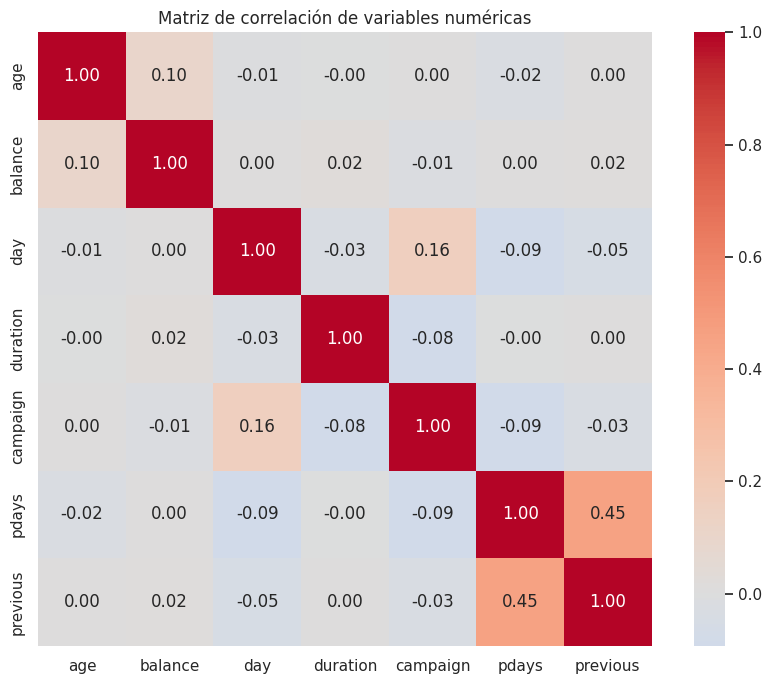

In [12]:
variables_numericas_eda = [
    "age", "balance", "day", "duration",
    "campaign", "pdays", "previous"
]

correlaciones = df[variables_numericas_eda].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

## Interpretación

La matriz de correlación muestra que la mayoría de las variables numéricas tiene relaciones lineales débiles entre sí. La asociación más alta se observa entre pdays y previous, con un valor de 0,45, considerado moderado. El resto de las correlaciones se encuentra principalmente cerca de cero, por lo que no se evidencia una multicolinealidad fuerte. Estos resultados deben interpretarse con cautela, ya que la correlación solo mide relaciones lineales y no demuestra causalidad. Asimismo, esta matriz no permite identificar directamente qué variables explican la suscripción porque la variable objetivo "y" no está incluida.

## 9. Preparación para el modelado

In [13]:
df_modelo = df.copy()
df_modelo["y_num"] = df_modelo["y"].map({"no": 0, "yes": 1})#se conveirte en numero la variable objetivo

# pdays = -1 significa que el cliente no había sido contactado anteriormente.
df_modelo["previously_contacted"] = (df_modelo["pdays"] != -1).astype(int)

columnas_excluir = ["y", "y_num", "duration"]
X = df_modelo.drop(columns=columnas_excluir)
y = df_modelo["y_num"]

variables_numericas = [
    "age", "balance", "day", "campaign",
    "pdays", "previous", "previously_contacted"
]

variables_categoricas = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome"
]

print("Variables predictoras:", X.shape[1])
print("Numéricas:", variables_numericas)
print("Categóricas:", variables_categoricas)

Variables predictoras: 16
Numéricas: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'previously_contacted']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Decisión sobre `duration`

`duration` representa la duración de la última llamada. Esta información solo se conoce cuando la llamada ya terminó, por lo que no está disponible al momento de seleccionar a quién contactar. Utilizarla en el modelo final produciría fuga de información.

El modelo realista se entrenará **sin `duration`**. Más adelante se realizará un experimento separado para demostrar cómo esta variable puede aumentar artificialmente el desempeño.

## 10. División en entrenamiento, validacion y prueba

In [14]:
# Primera división: 80 % para desarrollo y 20 % para prueba final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE, #al ser un data set desbalanseado asegura que la proporción de las clases de la variable y sea aproximadamente la misma tanto en el conjunto de entrenamiento como en el de prueba
    stratify=y,
)

# Segunda división: del 80 % anterior se obtiene 60 % para entrenamiento
# y 20 % para validación respecto del dataset completo
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

tabla_division = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "registros": [len(X_train), len(X_val), len(X_test)],
    "porcentaje_dataset": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100,
    ],
    "porcentaje_yes": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})

tabla_division[["porcentaje_dataset", "porcentaje_yes"]] = (
    tabla_division[["porcentaje_dataset", "porcentaje_yes"]].round(2)
)

display(tabla_division)


,conjunto,registros,porcentaje_dataset,porcentaje_yes
0,Entrenamiento,27126,60.0,11.7
1,Validación,9042,20.0,11.7
2,Prueba,9043,20.0,11.7


El dataset se dividió en entrenamiento, validación y prueba para evaluar los modelos de manera más confiable. El conjunto de entrenamiento se utilizó para que los modelos aprendieran los patrones de los datos.

El conjunto de validación permitió comparar configuraciones y seleccionar el umbral de decisión y la profundidad del árbol sin utilizar la información de prueba.

Finalmente, el conjunto de prueba se reservó para medir el desempeño del modelo seleccionado con datos que no participaron en su entrenamiento ni en su configuración.

Si se hubiera realizado únicamente una división entre entrenamiento y prueba, habría sido necesario utilizar el conjunto de prueba para escoger el umbral o la profundidad.

Esto habría influido indirectamente en la selección del modelo y podría producir resultados demasiado optimistas.

Por esta razón se empleó una división estratificada de:


*   60 % para entrenamiento,
*   20 % para validación
*   y 20 % para prueba,

manteniendo aproximadamente la misma proporción de clientes que contrataron y no contrataron en los tres conjuntos.

## 11. Pipeline de transformación

In [15]:
# Variables numéricas: estandarización
pipeline_numerico = Pipeline(steps=[
    ("escalado", StandardScaler()),
])

# Variables categóricas: conversión a columnas numéricas
pipeline_categorico = Pipeline(steps=[
    ("codificacion",OneHotEncoder(handle_unknown="ignore")),
])

# Aplicar cada transformación al tipo de variable correspondiente
preprocesamiento = ColumnTransformer(transformers=[
    ( "numericas",pipeline_numerico,variables_numericas),
    ( "categoricas",pipeline_categorico,variables_categoricas),
])

print("Pipeline de transformación preparado.")

Pipeline de transformación preparado.


El dataset contiene variables numéricas y categóricas que necesitan tratamientos diferentes. Las variables numéricas se estandarizan para colocarlas en escalas comparables, mientras que las categóricas se convierten en columnas binarias utilizando One-Hot Encoding. ColumnTransformer permite aplicar automáticamente cada procedimiento al grupo correcto de variables. De esta forma, los datos quedan completamente numéricos y pueden ser utilizados por los modelos de Machine Learning.

El análisis de calidad determinó que el dataset no contiene valores nulos ni textos vacíos. En consecuencia, no fue necesario aplicar técnicas de imputación. El preprocesamiento se limitó a estandarizar las variables numéricas y codificar las variables categóricas.

## 12. Función de evaluación

In [16]:
resultados_modelos = []

def evaluar_modelo(nombre, modelo, mostrar_matriz=True):
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultado = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred_test),
        "Precision": precision_score(y_test, pred_test, zero_division=0),
        "Recall": recall_score(y_test, pred_test, zero_division=0),
        "F1 entrenamiento": f1_score(y_train, pred_train, zero_division=0),
        "F1 prueba": f1_score(y_test, pred_test, zero_division=0),
    }

    print(nombre)
    print("-" * len(nombre))
    print(classification_report(
        y_test,
        pred_test,
        target_names=["No contrató", "Sí contrató"],
        zero_division=0,
    ))

    if mostrar_matriz:
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            pred_test,
            display_labels=["No contrató", "Sí contrató"],
            cmap="Blues",
            colorbar=False,
        )
        plt.title(f"Matriz de confusión - {nombre}")
        plt.show()

    return resultado

Esta funcion se utiliza para almacenar las métricas obtenidas por cada modelo y posteriormente construir una tabla comparativa.

## 13. Modelo 1: regresión logística

La regresión logística es adecuada porque la variable objetivo tiene dos categorías. Se utiliza como modelo base por su sencillez e interpretabilidad.

Regresión logística
-------------------
              precision    recall  f1-score   support

 No contrató       0.90      0.99      0.94      7985
 Sí contrató       0.66      0.17      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



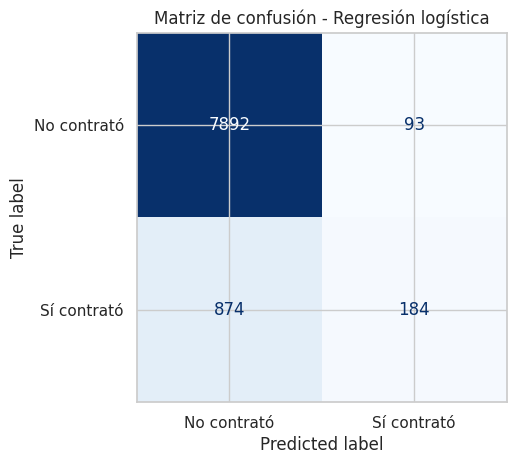

In [17]:
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    ("modelo", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

modelo_logistico.fit(X_train, y_train)

resultado_logistico = evaluar_modelo(
    "Regresión logística",
    modelo_logistico,
)
resultados_modelos.append(resultado_logistico)

In [18]:
import pandas as pd
from sklearn.metrics import confusion_matrix
pd.set_option("display.max_colwidth", None)

# Obtener predicciones
pred_test = modelo_logistico.predict(X_test)

# Crear matriz de confusión
matriz = confusion_matrix(
    y_test,
    pred_test,
    labels=[0, 1]
)

# Extraer resultados
verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = (
    matriz.ravel()
)

# Calcular porcentajes dentro de cada clase real
total_no_contrato = verdaderos_negativos + falsos_positivos
total_si_contrato = verdaderos_positivos + falsos_negativos

tabla_interpretacion = pd.DataFrame({
    "Resultado": [
        "Verdadero negativo",
        "Falso positivo",
        "Falso negativo",
        "Verdadero positivo"
    ],
    "Cantidad": [
        verdaderos_negativos,
        falsos_positivos,
        falsos_negativos,
        verdaderos_positivos
    ],
    "Porcentaje dentro de la clase real": [
        verdaderos_negativos / total_no_contrato * 100,
        falsos_positivos / total_no_contrato * 100,
        falsos_negativos / total_si_contrato * 100,
        verdaderos_positivos / total_si_contrato * 100
    ],
    "Interpretación": [
        "No contrató y el modelo predijo correctamente que no contrataría.",
        "No contrató, pero el modelo predijo que sí contrataría.",
        "Sí contrató, pero el modelo predijo que no contrataría.",
        "Sí contrató y el modelo predijo correctamente que contrataría."
    ]
})

tabla_interpretacion[
    "Porcentaje dentro de la clase real"
] = tabla_interpretacion[
    "Porcentaje dentro de la clase real"
].round(2)

display(tabla_interpretacion)

,Resultado,Cantidad,Porcentaje dentro de la clase real,Interpretación
0,Verdadero negativo,7892,98.84,No contrató y el modelo predijo correctamente que no contrataría.
1,Falso positivo,93,1.16,"No contrató, pero el modelo predijo que sí contrataría."
2,Falso negativo,874,82.61,"Sí contrató, pero el modelo predijo que no contrataría."
3,Verdadero positivo,184,17.39,Sí contrató y el modelo predijo correctamente que contrataría.


### Interpretación de las métricas

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los clientes clasificados como interesados, cuántos realmente contrataron.
- **Recall:** de los clientes que realmente contrataron, cuántos fueron detectados.
- **F1-score:** equilibrio entre precision y recall.

Debido al desbalance, el F1-score de la clase `yes` será la métrica principal.

La regresión logística obtiene una exactitud general del 89% y clasifica correctamente a casi todos los clientes que no contrataron con un 98.4%. Sin embargo, solo identifica al 17% de quienes sí contrataron, dejando sin detectar 874 casos positivos. Esto ocurre principalmente por el desbalance de la variable objetivo, ya que el modelo tiende a favorecer la clase mayoritaria no. Por lo tanto, la exactitud no representa completamente el desempeño y el modelo todavía no es adecuado si el objetivo principal es detectar clientes potencialmente interesados.

## 14. Cambio del umbral de decisión

In [19]:
# Comparación inicial realizada exclusivamente con validación
probabilidades_val = modelo_logistico.predict_proba(X_val)[:, 1]
resultados_umbrales_iniciales = []

for umbral in [0.50, 0.40]:
    prediccion_val = (probabilidades_val >= umbral).astype(int)

    resultados_umbrales_iniciales.append({
        "Umbral": umbral,
        "Accuracy validación": accuracy_score(y_val, prediccion_val),
        "Precision validación": precision_score(
            y_val, prediccion_val, zero_division=0
        ),
        "Recall validación": recall_score(
            y_val, prediccion_val, zero_division=0
        ),
        "F1 validación": f1_score(
            y_val, prediccion_val, zero_division=0
        ),
    })

tabla_umbrales_iniciales = pd.DataFrame(
    resultados_umbrales_iniciales
)
display(tabla_umbrales_iniciales.round(3))


,Umbral,Accuracy validación,Precision validación,Recall validación,F1 validación
0,0.5,0.894,0.677,0.188,0.294
1,0.4,0.894,0.618,0.250,0.356


### Interpretación

Al reducir el umbral de 0,50 a 0,40, el modelo clasifica más observaciones como posibles contratantes. Generalmente esto aumenta el recall y reduce los falsos negativos, aunque puede disminuir la precision y aumentar las llamadas innecesarias.

La comparación inicial y la búsqueda del mejor umbral se realizan con el conjunto de **validación**. El conjunto de **prueba no interviene en la selección** y se utiliza únicamente después de fijar el umbral.


In [20]:
# Evaluar en validación umbrales desde 0.05 hasta 0.90
umbrales_busqueda = np.arange(0.05, 0.91, 0.01)
resultados_umbrales = []

for umbral in umbrales_busqueda:
    prediccion_val = (probabilidades_val >= umbral).astype(int)
    matriz_val = confusion_matrix(
        y_val,
        prediccion_val,
        labels=[0, 1],
    )
    vn, fp, fn, vp = matriz_val.ravel()

    resultados_umbrales.append({
        "Umbral": round(float(umbral), 2),
        "Accuracy validación": accuracy_score(y_val, prediccion_val),
        "Precision validación": precision_score(
            y_val, prediccion_val, zero_division=0
        ),
        "Recall validación": recall_score(
            y_val, prediccion_val, zero_division=0
        ),
        "F1 validación": f1_score(
            y_val, prediccion_val, zero_division=0
        ),
        "Verdaderos negativos": vn,
        "Falsos positivos": fp,
        "Falsos negativos": fn,
        "Verdaderos positivos": vp
    })

tabla_umbrales = pd.DataFrame(resultados_umbrales)
indice_mejor = tabla_umbrales["F1 validación"].idxmax()
mejor_resultado_validacion = tabla_umbrales.loc[indice_mejor]
mejor_umbral = float(mejor_resultado_validacion["Umbral"])

print(f"Mejor umbral seleccionado en validación: {mejor_umbral:.2f}")
print(
    f"F1 de validación: "
    f"{mejor_resultado_validacion['F1 validación']:.3f}"
)
print(
    f"Precision de validación: "
    f"{mejor_resultado_validacion['Precision validación']:.3f}"
)
print(
    f"Recall de validación: "
    f"{mejor_resultado_validacion['Recall validación']:.3f}"
)


Mejor umbral seleccionado en validación: 0.18
F1 de validación: 0.457
Precision de validación: 0.434
Recall de validación: 0.483


In [21]:
# Mostrar los diez umbrales con mayor F1 en validación
mejores_umbrales = (
    tabla_umbrales
    .sort_values("F1 validación", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(
    mejores_umbrales.style
    .format({
        "Umbral": "{:.2f}",
        "Accuracy validación": "{:.3f}",
        "Precision validación": "{:.3f}",
        "Recall validación": "{:.3f}",
        "F1 validación": "{:.3f}",
    })
    .highlight_max(subset=["F1 validación"], color="green")
    .hide(axis="index")
)


Umbral,Accuracy validación,Precision validación,Recall validación,F1 validación,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos
0.18,0.866,0.434,0.483,0.457,7318,666,547,511
0.19,0.870,0.448,0.460,0.454,7383,601,571,487
0.20,0.875,0.464,0.443,0.454,7443,541,589,469
0.21,0.879,0.480,0.429,0.453,7492,492,604,454
0.22,0.882,0.493,0.419,0.453,7528,456,615,443
0.23,0.886,0.515,0.404,0.453,7582,402,631,427
0.24,0.888,0.527,0.393,0.450,7611,373,642,416
0.17,0.855,0.404,0.497,0.446,7208,776,532,526
0.25,0.889,0.534,0.381,0.445,7632,352,655,403
0.16,0.843,0.375,0.516,0.434,7074,910,512,546


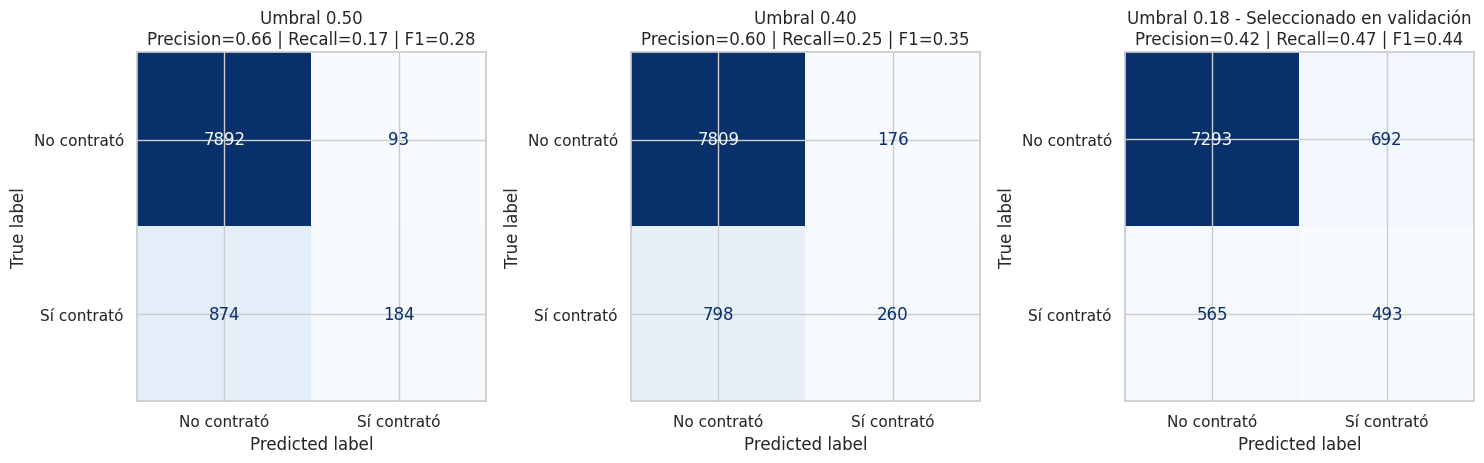

In [22]:
# El umbral ya fue seleccionado; ahora se evalúa en la prueba final
probabilidades_test = modelo_logistico.predict_proba(X_test)[:, 1]
umbrales_comparacion = []

for umbral in [0.50, 0.40, mejor_umbral]:
    if not any(
        np.isclose(umbral, valor)
        for valor in umbrales_comparacion
    ):
        umbrales_comparacion.append(float(umbral))

numero_columnas = len(umbrales_comparacion)
fig, axes = plt.subplots(
    1,
    numero_columnas,
    figsize=(5 * numero_columnas, 4.8),
)
axes = np.atleast_1d(axes)

resultados_comparacion = []

for posicion, umbral in enumerate(umbrales_comparacion):
    prediccion_test = (
        probabilidades_test >= umbral
    ).astype(int)

    matriz_test = confusion_matrix(
        y_test,
        prediccion_test,
        labels=[0, 1],
    )
    vn, fp, fn, vp = matriz_test.ravel()

    accuracy = accuracy_score(y_test, prediccion_test)
    precision = precision_score(
        y_test, prediccion_test, zero_division=0
    )
    recall = recall_score(
        y_test, prediccion_test, zero_division=0
    )
    f1 = f1_score(
        y_test, prediccion_test, zero_division=0
    )

    resultados_comparacion.append({
        "Umbral": umbral,
        "Accuracy prueba": accuracy,
        "Precision prueba": precision,
        "Recall prueba": recall,
        "F1 prueba": f1,
        "VN": vn,
        "FP": fp,
        "FN": fn,
        "VP": vp,
    })

    titulo_adicional = (
        " - Seleccionado en validación"
        if np.isclose(umbral, mejor_umbral)
        else ""
    )

    visualizacion = ConfusionMatrixDisplay(
        confusion_matrix=matriz_test,
        display_labels=["No contrató", "Sí contrató"],
    )
    visualizacion.plot(
        ax=axes[posicion],
        cmap="Blues",
        colorbar=False,
    )
    axes[posicion].set_title(
        f"Umbral {umbral:.2f}{titulo_adicional}\n"
        f"Precision={precision:.2f} | "
        f"Recall={recall:.2f} | F1={f1:.2f}"
    )

plt.tight_layout()
plt.show()


In [23]:
tabla_comparacion_test = pd.DataFrame(
    resultados_comparacion
).sort_values("Umbral", ascending=False)

display(
    tabla_comparacion_test.style
    .format({
        "Umbral": "{:.2f}",
        "Accuracy prueba": "{:.3f}",
        "Precision prueba": "{:.3f}",
        "Recall prueba": "{:.3f}",
        "F1 prueba": "{:.3f}",
    })
    .apply(
        lambda fila: [
            "background-color: green"
            if np.isclose(fila["Umbral"], mejor_umbral)
            else ""
            for _ in fila
        ],
        axis=1,
    )
    .hide(axis="index")
)

resultado_umbral_seleccionado = tabla_comparacion_test[
    np.isclose(tabla_comparacion_test["Umbral"], mejor_umbral)
].iloc[0]

print("Resultado final del umbral seleccionado:")
print(f"Umbral: {mejor_umbral:.2f}")
print(
    f"Accuracy de prueba: "
    f"{resultado_umbral_seleccionado['Accuracy prueba']:.3f}"
)
print(
    f"Precision de prueba: "
    f"{resultado_umbral_seleccionado['Precision prueba']:.3f}"
)
print(
    f"Recall de prueba: "
    f"{resultado_umbral_seleccionado['Recall prueba']:.3f}"
)
print(
    f"F1 de prueba: "
    f"{resultado_umbral_seleccionado['F1 prueba']:.3f}"
)


Umbral,Accuracy prueba,Precision prueba,Recall prueba,F1 prueba,VN,FP,FN,VP
0.50,0.893,0.664,0.174,0.276,7892,93,874,184
0.40,0.892,0.596,0.246,0.348,7809,176,798,260
0.18,0.861,0.416,0.466,0.440,7293,692,565,493


Resultado final del umbral seleccionado:
Umbral: 0.18
Accuracy de prueba: 0.861
Precision de prueba: 0.416
Recall de prueba: 0.466
F1 de prueba: 0.440


### Interpretación

El umbral final fue escogido exclusivamente por su mayor F1 en el conjunto de validación. Después de fijarlo, se aplicó al conjunto de prueba para obtener una evaluación independiente.

La disminución del umbral busca detectar una mayor proporción de clientes que realmente contrataron. El beneficio se observa en el aumento del recall y la reducción de falsos negativos; el costo suele ser una menor precision y un aumento de falsos positivos. Por ello, la selección debe interpretarse como un equilibrio entre encontrar clientes potenciales y evitar llamadas innecesarias.


## 15. Modelo 2: árbol de decisión

El árbol de decisión clasifica a los clientes mediante reglas sucesivas. Se eligió como segundo modelo porque puede representar relaciones no lineales e interacciones entre variables, mientras que la regresión logística funciona como un modelo lineal de referencia.

Las variables numéricas se mantienen en su escala original porque los árboles comparan valores mediante puntos de corte y no necesitan estandarización. Las variables categóricas sí se convierten con One-Hot Encoding.

Se utilizará una función para construir árboles con distintas profundidades y, opcionalmente, con balanceo de clases. Esto garantiza que todos los árboles se entrenen con el mismo preprocesamiento.


In [24]:
# Preprocesamiento específico para árboles
preprocesamiento_arbol = ColumnTransformer(transformers=[
    ("numericas", "passthrough", variables_numericas),
    (
        "categoricas",
        clone(pipeline_categorico),
        variables_categoricas,
    ),
])


def construir_arbol(profundidad, balancear=False):
    # Construye un árbol con una profundidad y balanceo determinados.
    peso_clases = "balanced" if balancear else None

    return Pipeline(steps=[
        ("preprocesamiento", clone(preprocesamiento_arbol)),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=profundidad,
                class_weight=peso_clases,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


print("Función para construir árboles preparada.")
print("Profundidades que se evaluarán: 2, 6, 8 y 12.")


Función para construir árboles preparada.
Profundidades que se evaluarán: 2, 6, 8 y 12.


## 16. Profundidad y análisis de sobreajuste

La profundidad controla cuántas reglas puede aprender el árbol:




Profundidad,F1 entrenamiento,Accuracy validación,Precision validación,Recall validación,F1 validación,Brecha F1
2,0.280,0.895,0.670,0.198,0.305,-0.025
6,0.314,0.895,0.666,0.203,0.311,0.002
8,0.375,0.895,0.650,0.221,0.330,0.045
10,0.441,0.893,0.602,0.245,0.348,0.093
12,0.492,0.891,0.573,0.253,0.351,0.141


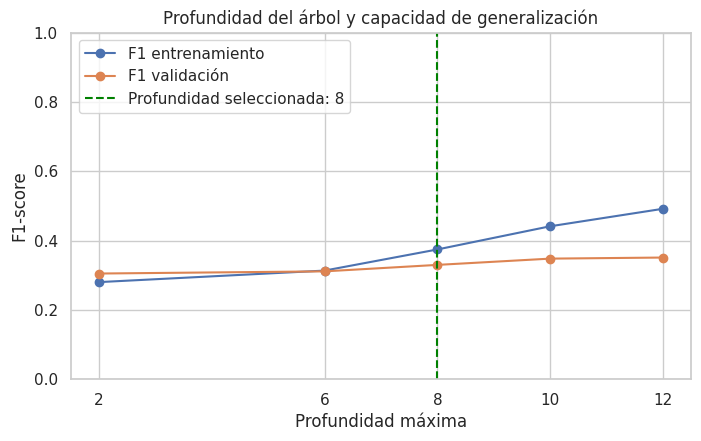

Profundidad con mayor F1 de validación: 12
Profundidad seleccionada por equilibrio y menor sobreajuste: 8

Resultados en prueba del árbol seleccionado:
              precision    recall  f1-score   support

 No contrató       0.90      0.98      0.94      7985
 Sí contrató       0.63      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.59      0.63      9043
weighted avg       0.87      0.89      0.87      9043



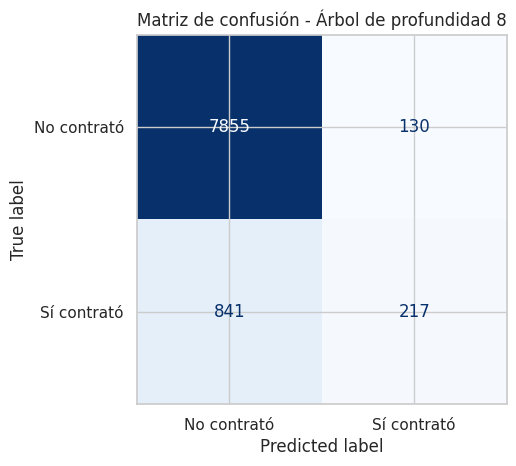

In [25]:
# Profundidades que se van a comparar
profundidades = [2, 6, 8, 10, 12]

resultados_profundidad = []
modelos_arbol = {}

for profundidad in profundidades:

    modelo_temporal = construir_arbol(
        profundidad=profundidad,
        balancear=False
    )

    # Entrenamiento del modelo
    modelo_temporal.fit(X_train, y_train)

    # Guardar cada modelo para utilizarlo posteriormente
    modelos_arbol[profundidad] = modelo_temporal

    # Predicciones de entrenamiento y validación
    pred_train = modelo_temporal.predict(X_train)
    pred_val = modelo_temporal.predict(X_val)

    f1_train = f1_score(
        y_train,
        pred_train,
        zero_division=0
    )

    f1_val = f1_score(
        y_val,
        pred_val,
        zero_division=0
    )

    resultados_profundidad.append({
        "Profundidad": profundidad,
        "F1 entrenamiento": f1_train,
        "Accuracy validación": accuracy_score(
            y_val,
            pred_val
        ),
        "Precision validación": precision_score(
            y_val,
            pred_val,
            zero_division=0
        ),
        "Recall validación": recall_score(
            y_val,
            pred_val,
            zero_division=0
        ),
        "F1 validación": f1_val,
        "Brecha F1": f1_train - f1_val
    })

# Crear tabla comparativa
tabla_profundidad = pd.DataFrame(
    resultados_profundidad
)

display(
    tabla_profundidad.style
    .format({
        "F1 entrenamiento": "{:.3f}",
        "Accuracy validación": "{:.3f}",
        "Precision validación": "{:.3f}",
        "Recall validación": "{:.3f}",
        "F1 validación": "{:.3f}",
        "Brecha F1": "{:.3f}"
    })
    .apply(
        lambda fila: [
            "background-color: green"
            if fila["Profundidad"] == 8
            else ""
            for _ in fila
        ],
        axis=1
    )
    .hide(axis="index")
)

# Gráfico de entrenamiento y validación
plt.figure(figsize=(8, 4.5))

plt.plot(
    tabla_profundidad["Profundidad"],
    tabla_profundidad["F1 entrenamiento"],
    marker="o",
    label="F1 entrenamiento"
)

plt.plot(
    tabla_profundidad["Profundidad"],
    tabla_profundidad["F1 validación"],
    marker="o",
    label="F1 validación"
)

# Marcar la profundidad seleccionada
plt.axvline(
    x=8,
    color="green",
    linestyle="--",
    label="Profundidad seleccionada: 8"
)

plt.title("Profundidad del árbol y capacidad de generalización")
plt.xlabel("Profundidad máxima")
plt.ylabel("F1-score")
plt.xticks(profundidades)
plt.ylim(0, 1)
plt.legend()
plt.show()

# La profundidad 8 se selecciona por decisión metodológica
profundidad_seleccionada = 8
modelo_arbol = modelos_arbol[profundidad_seleccionada]

# Mostrar cuál profundidad obtuvo el mayor F1
profundidad_mayor_f1 = int(
    tabla_profundidad.loc[
        tabla_profundidad["F1 validación"].idxmax(),
        "Profundidad"
    ]
)

print(
    "Profundidad con mayor F1 de validación:",
    profundidad_mayor_f1
)

print(
    "Profundidad seleccionada por equilibrio y menor sobreajuste:",
    profundidad_seleccionada
)

# Evaluación final del árbol de profundidad 8
pred_arbol_test = modelo_arbol.predict(X_test)

print("\nResultados en prueba del árbol seleccionado:")

print(
    classification_report(
        y_test,
        pred_arbol_test,
        target_names=[
            "No contrató",
            "Sí contrató"
        ],
        zero_division=0
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_arbol_test,
    display_labels=[
        "No contrató",
        "Sí contrató"
    ],
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Matriz de confusión - Árbol de profundidad 8"
)

plt.show()

- **Profundidad 2:** árbol sencillo, con mayor posibilidad de subajuste.
- **Profundidad 6:** árbol de complejidad intermedia.
- **Profundidad 8:** árbol con mayor capacidad de aprendizaje, pero todavía con una diferencia controlada entre entrenamiento y validación.
- **Profundidades 10 y 12:** árboles más complejos, capaces de aprender más detalles, pero con un mayor riesgo de sobreajuste.

Aunque la profundidad 12 obtuvo el mayor F1 de validación, también presentó una diferencia considerable entre el F1 de entrenamiento y validación. Esto indica que el árbol comienza a aprender características demasiado específicas de los datos de entrenamiento.

Por esta razón, se seleccionó la profundidad 8 como un equilibrio entre desempeño, sencillez y capacidad de generalización. El conjunto de prueba no participa en esta decisión y se utiliza solamente para realizar la evaluación final del árbol seleccionado.

## 17. Ajuste por desbalance

La clase `yes` representa solamente el 11,7 % de los registros. Como consecuencia, los modelos pueden favorecer la clase mayoritaria `no` y dejar sin detectar a muchos clientes interesados.
Se utiliza `class_weight="balanced"` como experimento de mejora. Esta opción aumenta la importancia de los errores cometidos sobre la clase minoritaria durante el entrenamiento.

Para medir únicamente el efecto del balanceo, el árbol normal y el árbol balanceado utilizan la misma profundidad seleccionada: 8.

De esta forma, la diferencia entre ambos resultados se debe al peso de las clases y no a un cambio adicional de profundidad.

,Modelo,Precision validación,Recall validación,F1 validación,Precision prueba,Recall prueba,F1 prueba
0,Regresión logística balanceada,0.267,0.629,0.375,0.266,0.629,0.373


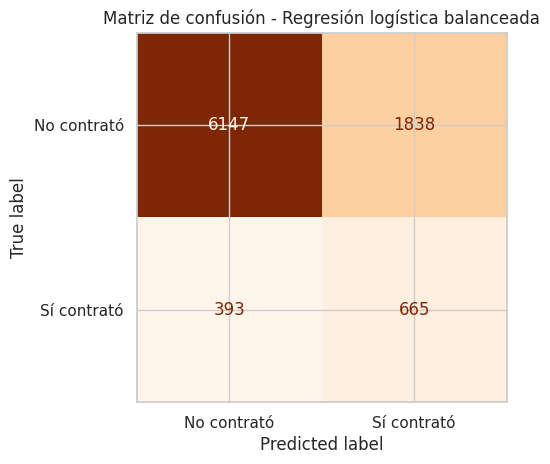

In [26]:
modelo_logistico_balanceado = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesamiento)),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

modelo_logistico_balanceado.fit(X_train, y_train)

pred_log_balanceado_val = modelo_logistico_balanceado.predict(X_val)
pred_log_balanceado_test = modelo_logistico_balanceado.predict(X_test)

tabla_log_balanceado = pd.DataFrame([{
    "Modelo": "Regresión logística balanceada",
    "Precision validación": precision_score(
        y_val, pred_log_balanceado_val, zero_division=0
    ),
    "Recall validación": recall_score(
        y_val, pred_log_balanceado_val, zero_division=0
    ),
    "F1 validación": f1_score(
        y_val, pred_log_balanceado_val, zero_division=0
    ),
    "Precision prueba": precision_score(
        y_test, pred_log_balanceado_test, zero_division=0
    ),
    "Recall prueba": recall_score(
        y_test, pred_log_balanceado_test, zero_division=0
    ),
    "F1 prueba": f1_score(
        y_test, pred_log_balanceado_test, zero_division=0
    ),
}])
display(tabla_log_balanceado.round(3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_log_balanceado_test,
    display_labels=["No contrató", "Sí contrató"],
    cmap="Oranges",
    colorbar=False,
)
plt.title("Matriz de confusión - Regresión logística balanceada")
plt.show()


,Modelo,Profundidad,F1 entrenamiento,Precision validación,Recall validación,F1 validación
0,Árbol sin balanceo,8,0.375,0.650,0.221,0.330
1,Árbol balanceado,8,0.450,0.358,0.560,0.437


Resultados en prueba del árbol balanceado de profundidad 8:
              precision    recall  f1-score   support

 No contrató       0.93      0.86      0.90      7985
 Sí contrató       0.34      0.55      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.70      0.66      9043
weighted avg       0.87      0.82      0.84      9043



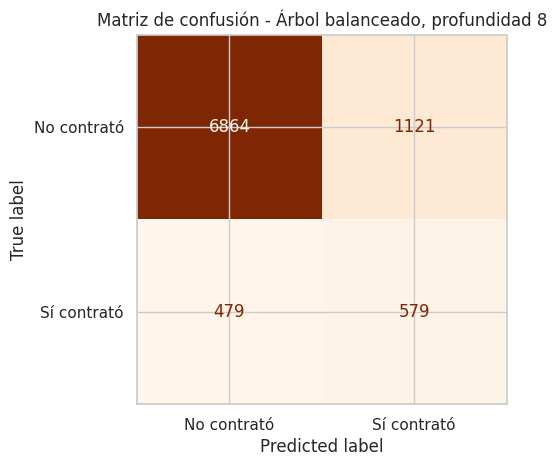

In [27]:
# Árbol balanceado con la misma profundidad seleccionada
mejor_profundidad_arbol_balanceado = 8

modelo_arbol_balanceado = construir_arbol(
    profundidad=mejor_profundidad_arbol_balanceado,
    balancear=True,
)
modelo_arbol_balanceado.fit(X_train, y_train)

pred_arbol_balanceado_train = modelo_arbol_balanceado.predict(X_train)
pred_arbol_balanceado_val = modelo_arbol_balanceado.predict(X_val)
pred_arbol_balanceado_test = modelo_arbol_balanceado.predict(X_test)

comparacion_balanceo_arbol = pd.DataFrame([
    {
        "Modelo": "Árbol sin balanceo",
        "Profundidad": 8,
        "F1 entrenamiento": f1_score(
            y_train,
            modelo_arbol.predict(X_train),
            zero_division=0,
        ),
        "Precision validación": precision_score(
            y_val,
            modelo_arbol.predict(X_val),
            zero_division=0,
        ),
        "Recall validación": recall_score(
            y_val,
            modelo_arbol.predict(X_val),
            zero_division=0,
        ),
        "F1 validación": f1_score(
            y_val,
            modelo_arbol.predict(X_val),
            zero_division=0,
        ),
    },
    {
        "Modelo": "Árbol balanceado",
        "Profundidad": 8,
        "F1 entrenamiento": f1_score(
            y_train,
            pred_arbol_balanceado_train,
            zero_division=0,
        ),
        "Precision validación": precision_score(
            y_val,
            pred_arbol_balanceado_val,
            zero_division=0,
        ),
        "Recall validación": recall_score(
            y_val,
            pred_arbol_balanceado_val,
            zero_division=0,
        ),
        "F1 validación": f1_score(
            y_val,
            pred_arbol_balanceado_val,
            zero_division=0,
        ),
    },
])

display(comparacion_balanceo_arbol.round(3))

print("Resultados en prueba del árbol balanceado de profundidad 8:")
print(classification_report(
    y_test,
    pred_arbol_balanceado_test,
    target_names=["No contrató", "Sí contrató"],
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_arbol_balanceado_test,
    display_labels=["No contrató", "Sí contrató"],
    cmap="Oranges",
    colorbar=False,
)
plt.title("Matriz de confusión - Árbol balanceado, profundidad 8")
plt.show()


### Interpretación

El balanceo mejora considerablemente la capacidad del árbol para encontrar clientes interesados. Con profundidad 8, el recall de validación aumenta de aproximadamente 0,221 a 0,560, mientras que el F1 de validación aumenta de 0,330 a 0,437.

En prueba, el árbol balanceado alcanza aproximadamente 0,341 de precision, 0,547 de recall y 0,420 de F1. Esto significa que identifica a más de la mitad de los clientes que realmente contrataron. El costo es una menor precision y una mayor cantidad de falsos positivos.

`class_weight="balanced"` no modifica los registros ni crea datos artificiales; solamente asigna mayor importancia a los errores sobre la clase minoritaria durante el entrenamiento.


## 18. Comparación final de modelos

Para que la comparación sea correcta, todas las alternativas utilizan los mismos conjuntos de entrenamiento, validación y prueba. La tabla incluye:

1. Regresión logística con umbral 0,50.
2. Regresión logística con el umbral seleccionado en validación.
3. Regresión logística balanceada.
4. Árbol sin balanceo de profundidad 8.
5. Árbol balanceado de profundidad 8.

Los dos árboles mantienen la misma profundidad para que la comparación permita observar específicamente el efecto del balanceo.
El modelo final se selecciona por el mayor F1 de validación. Las métricas del conjunto de prueba se utilizan posteriormente como una evaluación independiente



Modelo,Configuración,F1 entrenamiento,F1 validación,Accuracy prueba,Precision prueba,Recall prueba,F1 prueba,Seleccionado
Regresión logística - umbral validado,Umbral 0.18,0.441,0.457,0.861,0.416,0.466,0.440,Sí
Árbol balanceado,Profundidad 8,0.450,0.437,0.823,0.341,0.547,0.420,No
Regresión logística balanceada,class_weight=balanced,0.374,0.375,0.753,0.266,0.629,0.373,No
Árbol sin balanceo,Profundidad 8,0.375,0.330,0.893,0.625,0.205,0.309,No
"Regresión logística - umbral 0,50","Umbral 0,50",0.267,0.294,0.893,0.664,0.174,0.276,No


Modelo seleccionado mediante validación:
Regresión logística - umbral validado
Configuración: Umbral 0.18
F1 validación: 0.457
F1 prueba: 0.440


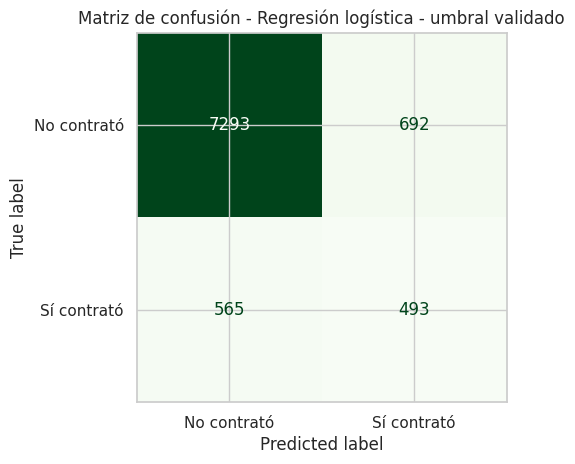

In [28]:
def predecir_con_umbral(modelo, datos, umbral):
    probabilidades = modelo.predict_proba(datos)[:, 1]
    return (probabilidades >= umbral).astype(int)


def crear_fila_comparacion(
    nombre,
    configuracion,
    pred_train,
    pred_val,
    pred_test,
):
    return {
        "Modelo": nombre,
        "Configuración": configuracion,
        "F1 entrenamiento": f1_score(
            y_train, pred_train, zero_division=0
        ),
        "F1 validación": f1_score(
            y_val, pred_val, zero_division=0
        ),
        "Accuracy prueba": accuracy_score(y_test, pred_test),
        "Precision prueba": precision_score(
            y_test, pred_test, zero_division=0
        ),
        "Recall prueba": recall_score(
            y_test, pred_test, zero_division=0
        ),
        "F1 prueba": f1_score(
            y_test, pred_test, zero_division=0
        ),
    }


# Predicciones de cada alternativa
predicciones_modelos = {
    "Regresión logística - umbral 0,50": {
        "configuracion": "Umbral 0,50",
        "train": predecir_con_umbral(modelo_logistico, X_train, 0.50),
        "val": predecir_con_umbral(modelo_logistico, X_val, 0.50),
        "test": predecir_con_umbral(modelo_logistico, X_test, 0.50),
    },
    "Regresión logística - umbral validado": {
        "configuracion": f"Umbral {mejor_umbral:.2f}",
        "train": predecir_con_umbral(
            modelo_logistico, X_train, mejor_umbral
        ),
        "val": predecir_con_umbral(
            modelo_logistico, X_val, mejor_umbral
        ),
        "test": predecir_con_umbral(
            modelo_logistico, X_test, mejor_umbral
        ),
    },
    "Regresión logística balanceada": {
        "configuracion": "class_weight=balanced",
        "train": modelo_logistico_balanceado.predict(X_train),
        "val": modelo_logistico_balanceado.predict(X_val),
        "test": modelo_logistico_balanceado.predict(X_test),
    },
    "Árbol sin balanceo": {
        "configuracion": f"Profundidad {profundidad_seleccionada}",
        "train": modelo_arbol.predict(X_train),
        "val": modelo_arbol.predict(X_val),
        "test": modelo_arbol.predict(X_test),
    },
    "Árbol balanceado": {
        "configuracion": (
            f"Profundidad {mejor_profundidad_arbol_balanceado}"
        ),
        "train": modelo_arbol_balanceado.predict(X_train),
        "val": modelo_arbol_balanceado.predict(X_val),
        "test": modelo_arbol_balanceado.predict(X_test),
    },
}

resultados_modelos = []
for nombre, predicciones in predicciones_modelos.items():
    resultados_modelos.append(crear_fila_comparacion(
        nombre=nombre,
        configuracion=predicciones["configuracion"],
        pred_train=predicciones["train"],
        pred_val=predicciones["val"],
        pred_test=predicciones["test"],
    ))

tabla_modelos = pd.DataFrame(resultados_modelos)

# La selección se realiza por validación, no por prueba
indice_modelo_seleccionado = tabla_modelos["F1 validación"].idxmax()
nombre_modelo_seleccionado = tabla_modelos.loc[
    indice_modelo_seleccionado,
    "Modelo",
]
tabla_modelos["Seleccionado"] = np.where(
    tabla_modelos["Modelo"] == nombre_modelo_seleccionado,
    "Sí",
    "No",
)
tabla_modelos = tabla_modelos.sort_values(
    "F1 validación",
    ascending=False,
).reset_index(drop=True)

columnas_formato = {
    "F1 entrenamiento": "{:.3f}",
    "F1 validación": "{:.3f}",
    "Accuracy prueba": "{:.3f}",
    "Precision prueba": "{:.3f}",
    "Recall prueba": "{:.3f}",
    "F1 prueba": "{:.3f}",
}

display(
    tabla_modelos.style
    .format(columnas_formato)
    .apply(
        lambda fila: [
            "background-color: green"
            if fila["Seleccionado"] == "Sí"
            else ""
            for _ in fila
        ],
        axis=1,
    )
    .hide(axis="index")
)

fila_modelo_final = tabla_modelos[
    tabla_modelos["Seleccionado"] == "Sí"
].iloc[0]

print("Modelo seleccionado mediante validación:")
print(nombre_modelo_seleccionado)
print("Configuración:", fila_modelo_final["Configuración"])
print(f"F1 validación: {fila_modelo_final['F1 validación']:.3f}")
print(f"F1 prueba: {fila_modelo_final['F1 prueba']:.3f}")

pred_final_test = predicciones_modelos[
    nombre_modelo_seleccionado
]["test"]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_final_test,
    display_labels=["No contrató", "Sí contrató"],
    cmap="Greens",
    colorbar=False,
)
plt.title(f"Matriz de confusión - {nombre_modelo_seleccionado}")
plt.show()


### Interpretación y criterio de selección

La regresión logística con umbral validado obtiene el mayor F1 de validación, por lo que se selecciona como modelo final. Con un umbral de 0,18 alcanza aproximadamente 0,416 de precision, 0,466 de recall y 0,440 de F1 en prueba.

El árbol balanceado de profundidad 8 presenta un F1 de prueba cercano a 0,420 y un recall de 0,547. Aunque su F1 es ligeramente menor, logra detectar una proporción mayor de clientes interesados, pero también genera más falsos positivos.

El árbol sin balanceo de profundidad 8 conserva una precision relativamente alta, pero su recall de aproximadamente 0,205 demuestra que deja sin detectar a la mayoría de los clientes que contrataron.

Por el desbalance de la variable objetivo, el modelo no se selecciona únicamente por accuracy. Se prioriza el F1 de validación y se revisan precision, recall, sobreajuste y facilidad de interpretación.


## 19. Importancia de variables del mejor árbol

Aunque el modelo final puede ser una regresión logística, el árbol permite examinar qué variables utilizó con mayor frecuencia para separar a los clientes.

Para que el análisis sea coherente, se comparan los mejores árboles normal y balanceado mediante su F1 de validación. La importancia se obtiene del árbol que generalizó mejor, no de una profundidad elegida arbitrariamente.


Árbol utilizado para calcular la importancia:
Árbol balanceado - profundidad 8


,importancia
poutcome_success,0.2867
contact_unknown,0.1597
housing_yes,0.0784
day,0.0713
balance,0.0501
month_aug,0.0448
month_jul,0.0427
month_nov,0.0301
age,0.0273
month_jan,0.0268


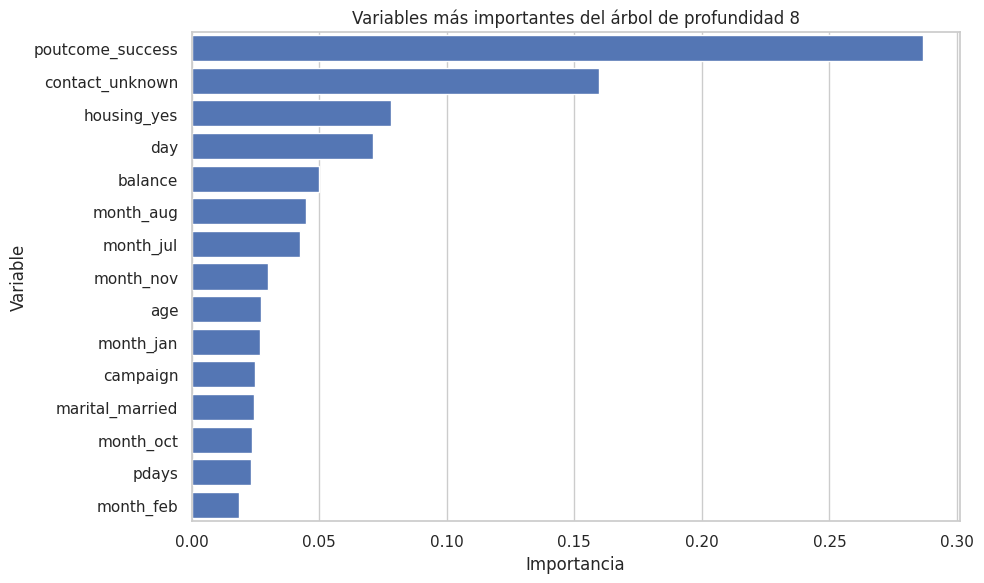

In [29]:
# Comparar los dos árboles de profundidad 8 mediante validación
f1_val_arbol = f1_score(
    y_val,
    modelo_arbol.predict(X_val),
    zero_division=0,
)

f1_val_arbol_balanceado = f1_score(
    y_val,
    modelo_arbol_balanceado.predict(X_val),
    zero_division=0,
)

if f1_val_arbol_balanceado >= f1_val_arbol:
    arbol_para_importancia = modelo_arbol_balanceado
    nombre_arbol_importancia = "Árbol balanceado - profundidad 8"
else:
    arbol_para_importancia = modelo_arbol
    nombre_arbol_importancia = "Árbol sin balanceo - profundidad 8"

preprocesador_importancia = arbol_para_importancia.named_steps[
    "preprocesamiento"
]
clasificador_importancia = arbol_para_importancia.named_steps["modelo"]

nombres_variables = preprocesador_importancia.get_feature_names_out()
nombres_variables = (
    pd.Index(nombres_variables)
    .str.replace("numericas__", "", regex=False)
    .str.replace("categoricas__", "", regex=False)
)

importancias = pd.Series(
    clasificador_importancia.feature_importances_,
    index=nombres_variables,
).sort_values(ascending=False).head(15)

print("Árbol utilizado para calcular la importancia:")
print(nombre_arbol_importancia)
display(importancias.rename("importancia").to_frame().round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importancias.values,
    y=importancias.index,
    color="#4472C4",
)
plt.title("Variables más importantes del árbol de profundidad 8")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


### Interpretación

La importancia representa cuánto contribuyó cada variable a las divisiones realizadas por el árbol. Una importancia mayor significa que la variable fue más útil para separar clientes durante el entrenamiento.

Este resultado ayuda a explicar el comportamiento del árbol, pero no indica causalidad. Por ejemplo, si  `poutcome_success` aparece entre las variables principales, significa que un resultado exitoso anterior ayuda a distinguir clientes, no que garantice una nueva contratación.


## 20. Experimento de fuga de información con `duration`

`duration` representa la duración de la llamada y solamente se conoce cuando la conversación terminó. Para demostrar su efecto, se entrenará otra regresión logística que incluye esta variable.

La comparación utiliza exactamente los mismos registros de entrenamiento, validación y prueba. El único cambio es incluir `duration`. Ambos modelos usan el umbral estándar 0,50 para que la comparación sea equivalente.


In [30]:
X_con_duration = df_modelo.drop(columns=["y", "y_num"])
variables_numericas_duration = variables_numericas + ["duration"]

# Reutilizar exactamente los mismos índices de las divisiones originales
X_train_duration = X_con_duration.loc[X_train.index]
X_val_duration = X_con_duration.loc[X_val.index]1
X_test_duration = X_con_duration.loc[X_test.index]

preprocesamiento_duration = ColumnTransformer(transformers=[
    (
        "numericas",
        clone(pipeline_numerico),
        variables_numericas_duration,
    ),
    (
        "categoricas",
        clone(pipeline_categorico),
        variables_categoricas,
    ),
])

modelo_con_duration = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_duration),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
    ),
])
modelo_con_duration.fit(X_train_duration, y_train)

# Comparación equivalente: misma regresión y umbral 0,50
pred_sin_duration_val = modelo_logistico.predict(X_val)
pred_sin_duration_test = modelo_logistico.predict(X_test)
pred_con_duration_val = modelo_con_duration.predict(X_val_duration)
pred_con_duration_test = modelo_con_duration.predict(X_test_duration)

comparacion_duration = pd.DataFrame([
    {
        "Escenario": "Modelo realista sin duration",
        "F1 validación": f1_score(
            y_val, pred_sin_duration_val, zero_division=0
        ),
        "Accuracy prueba": accuracy_score(
            y_test, pred_sin_duration_test
        ),
        "Precision prueba": precision_score(
            y_test, pred_sin_duration_test, zero_division=0
        ),
        "Recall prueba": recall_score(
            y_test, pred_sin_duration_test, zero_division=0
        ),
        "F1 prueba": f1_score(
            y_test, pred_sin_duration_test, zero_division=0
        ),
    },
    {
        "Escenario": "Modelo de referencia con duration",
        "F1 validación": f1_score(
            y_val, pred_con_duration_val, zero_division=0
        ),
        "Accuracy prueba": accuracy_score(
            y_test, pred_con_duration_test
        ),
        "Precision prueba": precision_score(
            y_test, pred_con_duration_test, zero_division=0
        ),
        "Recall prueba": recall_score(
            y_test, pred_con_duration_test, zero_division=0
        ),
        "F1 prueba": f1_score(
            y_test, pred_con_duration_test, zero_division=0
        ),
    },
])

display(comparacion_duration.round(3))


,Escenario,F1 validación,Accuracy prueba,Precision prueba,Recall prueba,F1 prueba
0,Modelo realista sin duration,0.294,0.893,0.664,0.174,0.276
1,Modelo de referencia con duration,0.457,0.902,0.649,0.348,0.453


### Interpretación

El modelo con `duration` obtiene un F1 considerablemente mayor que el modelo equivalente sin esa variable. Sin embargo, esto no significa que sea la mejor alternativa operativa.

La duración no está disponible cuando el banco debe decidir a quién llamar. Su inclusión permite que el modelo utilice información del resultado de una llamada ya realizada, lo que constituye fuga de información. Por esta razón, `duration` se conserva únicamente como demostración y permanece excluida del modelo final.

## 21. Consideraciones éticas

- Las variables `age`, `job`, `education` y `marital` podrían producir segmentaciones injustas.
- El modelo no debe utilizarse para excluir automáticamente a una persona.
- Los falsos positivos pueden generar llamadas innecesarias.
- Los falsos negativos pueden dejar fuera a clientes potencialmente interesados.
- Las predicciones deben apoyar la decisión humana y no sustituirla.
- Los patrones históricos pueden contener sesgos de campañas anteriores.

## 22. Limitaciones



1.   Los datos corresponden a campañas realizadas por una institución bancaria
portuguesa entre 2008 y 2010.
2.   Los resultados no deben generalizarse directamente a otras instituciones, países o periodos.
1.   La clase positiva está desbalanceada y representa solamente el 11,7 % de los registros.
1.   Algunas variables contienen la categoría unknown.
2.   pdays = -1 representa ausencia de contacto anterior y no un número negativo de días.
1.   duration debe excluirse para realizar predicciones antes de la llamada.
2.   La profundidad 8 se seleccionó como un compromiso entre desempeño, sencillez y menor riesgo de sobreajuste, aunque la profundidad 12 obtuvo un F1 de validación ligeramente mayor.
1.  El umbral de 0,18 fue seleccionado con los datos de validación y podría cambiar al trabajar con otra población.
2.   Un buen desempeño estadístico no garantiza el mismo comportamiento con datos futuros.









## 23. Resumen automático de resultados

In [31]:
mejor = tabla_modelos[
    tabla_modelos["Seleccionado"] == "Sí"
].iloc[0]

fila_arbol_normal = tabla_modelos[
    tabla_modelos["Modelo"] == "Árbol sin balanceo"
].iloc[0]

fila_arbol_balanceado = tabla_modelos[
    tabla_modelos["Modelo"] == "Árbol balanceado"
].iloc[0]

resumen = f'''
### Resultados principales

- Se analizaron **{len(df):,} registros** y **{df.shape[1]} columnas**.
- La clase positiva representa **{y.mean() * 100:.2f} %** de las observaciones.
- El modelo seleccionado mediante validación fue **{mejor['Modelo']}**, con la configuración **{mejor['Configuración']}**.
- Resultados del modelo seleccionado en prueba:
  - Accuracy: **{mejor['Accuracy prueba']:.3f}**.
  - Precision: **{mejor['Precision prueba']:.3f}**.
  - Recall: **{mejor['Recall prueba']:.3f}**.
  - F1: **{mejor['F1 prueba']:.3f}**.
- El árbol de profundidad 8 sin balanceo obtuvo un F1 de prueba de **{fila_arbol_normal['F1 prueba']:.3f}**.
- El árbol balanceado de profundidad 8 obtuvo un F1 de prueba de **{fila_arbol_balanceado['F1 prueba']:.3f}** y un recall de **{fila_arbol_balanceado['Recall prueba']:.3f}**.
- El modelo operativo se mantiene sin `duration` para evitar fuga de información.
'''

display(Markdown(resumen))



### Resultados principales

- Se analizaron **45,211 registros** y **17 columnas**.
- La clase positiva representa **11.70 %** de las observaciones.
- El modelo seleccionado mediante validación fue **Regresión logística - umbral validado**, con la configuración **Umbral 0.18**.
- Resultados del modelo seleccionado en prueba:
  - Accuracy: **0.861**.
  - Precision: **0.416**.
  - Recall: **0.466**.
  - F1: **0.440**.
- El árbol de profundidad 8 sin balanceo obtuvo un F1 de prueba de **0.309**.
- El árbol balanceado de profundidad 8 obtuvo un F1 de prueba de **0.420** y un recall de **0.547**.
- El modelo operativo se mantiene sin `duration` para evitar fuga de información.


## Referencias

- Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306
- UCI Machine Learning Repository. *Bank Marketing*. https://archive.ics.uci.edu/dataset/222/bank+marketing